In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:

""" the above code calculates the average value of every numerical column, separately for people with and without diabetes.It splits the data based on the target Outcome column (where 0 usually means no diabetes and 1 means diabetes), and then finds the mean for each group.Breakdown of the Codegroupby('Outcome'): Sorts all the rows in your dataset into two distinct groups based on whether the patient tested positive or negative for diabetes..mean(): Computes the statistical average for all remaining columns (e.g., Glucose, BMI, BloodPressure, Age) within those groups.What You Will SeeThe resulting output is usually a summary table where each row is an outcome (0 or 1), and the columns are your clinical variables.This allows you to quickly compare health metrics, such as noticing that patients with diabetes (1) might have a significantly higher average Glucose level or BMI than those without (0)."""

" the above code calculates the average value of every numerical column, separately for people with and without diabetes.It splits the data based on the target Outcome column (where 0 usually means no diabetes and 1 means diabetes), and then finds the mean for each group.Breakdown of the Codegroupby('Outcome'): Sorts all the rows in your dataset into two distinct groups based on whether the patient tested positive or negative for diabetes..mean(): Computes the statistical average for all remaining columns (e.g., Glucose, BMI, BloodPressure, Age) within those groups.What You Will SeeThe resulting output is usually a summary table where each row is an outcome (0 or 1), and the columns are your clinical variables.This allows you to quickly compare health metrics, such as noticing that patients with diabetes (1) might have a significantly higher average Glucose level or BMI than those without (0)."

In [9]:
X = df.drop(columns = 'Outcome', axis=1)
y = df['Outcome']

In [10]:
"""In pandas, axis=1 means you are dropping a column rather than a row.It tells Python to look horizontally across the column headers to find and remove the 'Outcome' column, leaving you with just the predictor features (like Glucose and BMI) stored in X.Understanding Axes in Pandasaxis=0 (Rows): Operates vertically down the rows. If you used axis=0, pandas would look for a row named 'Outcome'.axis=1 (Columns): Operates horizontally across the columns. This is required when deleting a specific vertical column of data.          
axis=1 (Columns) ──>
          [Glucose]  [BloodPressure]  [BMI]  [Outcome]
axis=0      148            72         33.6       1
(Rows)       85            66         26.6       0
  │          89            66         28.1       0
  ▼
Why This is Done in Machine LearningThis step separates your data before training a model:X: Holds all your independent variables (features), with 'Outcome' removed.Y: Usually the next line of code, which isolates just the 'Outcome' column (the target variable)."""

"In pandas, axis=1 means you are dropping a column rather than a row.It tells Python to look horizontally across the column headers to find and remove the 'Outcome' column, leaving you with just the predictor features (like Glucose and BMI) stored in X.Understanding Axes in Pandasaxis=0 (Rows): Operates vertically down the rows. If you used axis=0, pandas would look for a row named 'Outcome'.axis=1 (Columns): Operates horizontally across the columns. This is required when deleting a specific vertical column of data.          \naxis=1 (Columns) ──>\n          [Glucose]  [BloodPressure]  [BMI]  [Outcome]\naxis=0      148            72         33.6       1\n(Rows)       85            66         26.6       0\n  │          89            66         28.1       0\n  ▼\nWhy This is Done in Machine LearningThis step separates your data before training a model:X: Holds all your independent variables (features), with 'Outcome' removed.Y: Usually the next line of code, which isolates just the 'Outc

In [11]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [12]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [13]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [14]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [15]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Outcome',axis=1),
                                                df['Outcome'],
                                                test_size = 0.2,
                                                stratify=y,
                                                random_state=2)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [17]:
scaler = StandardScaler()

In [18]:
scaler.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [19]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
scaler.mean_

array([  3.84505208, 120.89453125,  69.10546875,  20.53645833,
        79.79947917,  31.99257812,   0.4718763 ,  33.24088542])

In [21]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
619,0,119,0,0,0,32.4,0.141,24
329,6,105,70,32,68,30.8,0.122,37
13,1,189,60,23,846,30.1,0.398,59
476,2,105,80,45,191,33.7,0.711,29
45,0,180,66,39,0,42.0,1.893,25
...,...,...,...,...,...,...,...,...
303,5,115,98,0,0,52.9,0.209,28
592,3,132,80,0,0,34.4,0.402,44
559,11,85,74,0,0,30.1,0.300,35
725,4,112,78,40,0,39.4,0.236,38


In [22]:
X_train_scaled

array([[-1.14185152, -0.05929342, -3.57259724, ...,  0.05170968,
        -0.9992857 , -0.78628618],
       [ 0.63994726, -0.49745345,  0.04624525, ..., -0.15136112,
        -1.05666795,  0.31985461],
       [-0.84488505,  2.13150675, -0.47073225, ..., -0.24020459,
        -0.2231152 ,  2.19178518],
       ...,
       [ 2.12477957, -1.12339636,  0.25303625, ..., -0.24020459,
        -0.51908683,  0.14967911],
       [ 0.04601433, -0.27837344,  0.45982725, ...,  0.94014439,
        -0.71237443,  0.40494237],
       [-1.14185152, -1.09209922, -0.05715025, ...,  0.48323511,
        -0.70633419, -0.70119842]], shape=(614, 8))

In [23]:
# to convert above array into df
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [24]:
np.round(X_train.describe(),1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0
mean,3.8,121.5,69.5,20.7,83.2,32.2,0.5,33.3
std,3.4,31.8,19.6,16.1,118.6,8.0,0.3,11.7
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0
25%,1.0,99.2,64.0,0.0,0.0,27.5,0.2,24.0
50%,3.0,117.0,72.0,23.0,44.0,32.4,0.4,29.0
75%,6.0,141.0,80.0,32.8,130.0,36.6,0.6,41.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0


In [25]:
np.round(X_train_scaled.describe(),1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0
mean,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.1,-3.8,-3.6,-1.3,-0.7,-4.1,-1.2,-1.0
25%,-0.8,-0.7,-0.3,-1.3,-0.7,-0.6,-0.7,-0.8
50%,-0.3,-0.1,0.1,0.2,-0.3,0.1,-0.3,-0.4
75%,0.6,0.6,0.6,0.8,0.4,0.6,0.4,0.7
max,3.9,2.4,2.7,4.9,6.7,4.5,5.9,4.1


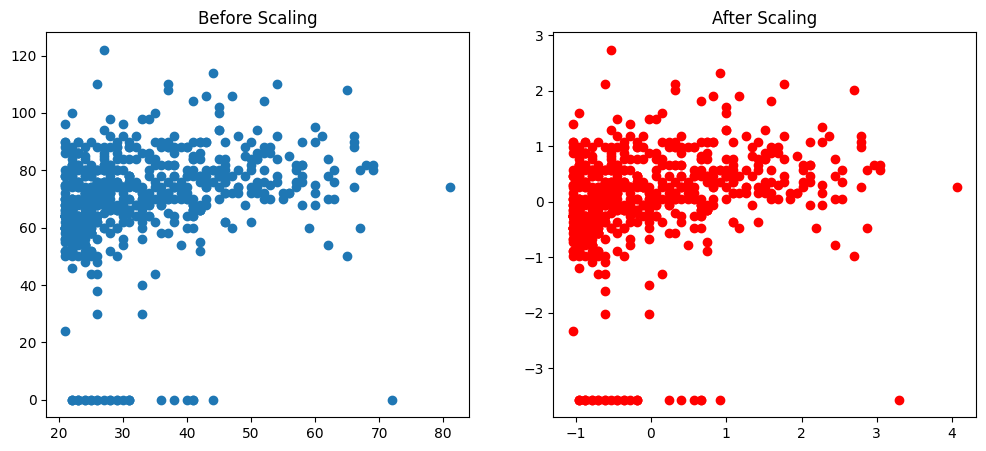

In [26]:
# comparison between before and after scaling and standardization
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['BloodPressure'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['BloodPressure'],color='red')
ax2.set_title('After Scaling')
plt.show()

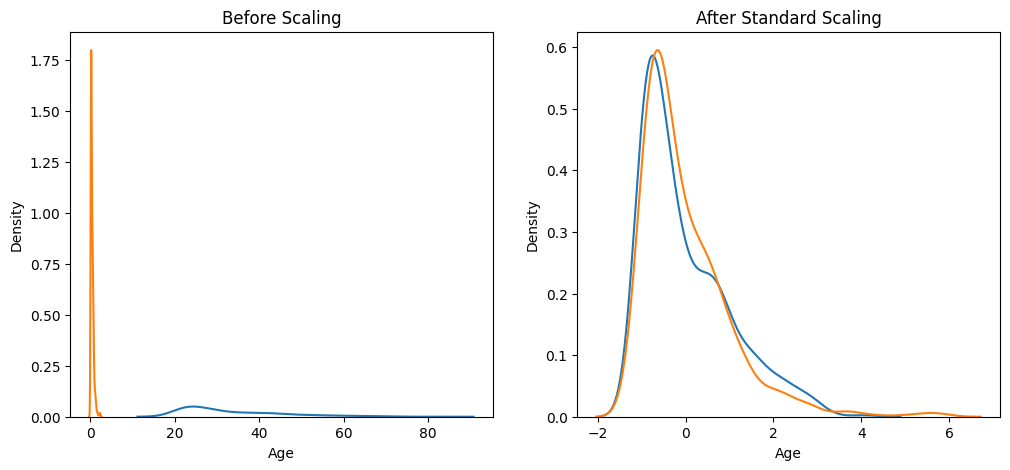

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
import seaborn as sns
# Before scaling 
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['DiabetesPedigreeFunction'],ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['DiabetesPedigreeFunction'],ax=ax2)
plt.show()

In [28]:
##Traning the model using support vector machine clf

In [29]:
classifier = svm.SVC(kernel='linear')

In [30]:
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
#Accuracy Score

In [32]:
#for training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)

In [33]:
training_data_accuracy

0.7833876221498371

In [34]:
#for test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,y_test)

In [35]:
test_data_accuracy

0.7727272727272727

In [36]:
import pickle

filename = 'diabetes_model.sav'

pickle.dump(classifier, open(filename, 'wb'))

print("Model saved successfully")

Model saved successfully


In [37]:
import pickle

pickle.dump(scaler, open('scaler.sav', 'wb'))

print("Scaler saved successfully")

Scaler saved successfully


In [38]:
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

prediction = loaded_model.predict([[6,148,72,35,0,33.6,0.627,50]])

print(prediction)

[1]


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
